In [2]:
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt
from quspin.operators import hamiltonian
from quspin.basis import spin_basis_1d
from quspin.tools.measurements import ent_entropy

In [3]:
"""
Interface Hamiltonian (QuSpin) — symmetry-adapted basis construction
=====================================================================

H = Σ_{j=1}^{J-1} α_j [ e^{-β(X_{j-1}+X_j)}              - Z_{j-1}Z_j       ]
  + α_J             [ e^{-β(X_{J-1}+Z_J Z_{J+1})}         - Z_{J-1}X_J       ]
  + Σ_{j=J+1}^{L}  α_j [ e^{-β(Z_{j-1}Z_j + Z_jZ_{j+1})} - X_j              ]
  + hx Σ_i X_i  +  hz Σ_i Z_i  +  tJ Z_J

SYMMETRY STRUCTURE
------------------
The unique non-trivial symmetry (when hz = tJ = 0) is:

    P_R = Π_{i=J}^{L+1} X_i    (partial Z2, right half)

Eigenvalues p_L = ±1.


symmetry-adapted basis
---------------------------------------------
1. Build P_R as an explicit matrix.
2. Diagonalize P_R → eigenvectors form the change-of-basis U = [U₊ | U₋].
   Since P_R² = I, its eigenvalues are exactly ±1, the subspaces are
   orthogonal complements, and dim(U₊) = dim(U₋) = 2^(N-1).
3. Rotate H into the P_R eigenbasis: H_rot = U† H U.
   By [H, P_L] = 0, this matrix is exactly block diagonal:
       H_rot = diag(H₊, H₋)
4. Diagonalize H₊ and H₋ separately — half the cost each.
5. Reconstruct full eigenvectors in the original basis if needed: V = U V_block.

Sites: 0 … L+1  (N = L+2 total, open boundary)
"""
# ================================================================
#  Hamiltonian
# ================================================================

def h_interface(L, J, a, beta, base, hx=0.0, hz=0.0, hxL=0.0, tJ=0.0):
    """
    Build the interface Hamiltonian as a QuSpin hamiltonian object.

    Parameters
    ----------
    L    : int   — j runs 1…L; chain has N = L+2 sites (0…L+1).
                   *** Basis MUST be spin_1half_basis_1d(L+2, pauli=True) ***
    J    : int   — interface position, 1-indexed  (1 <= J < L)
    a    : float — staggering parameter, |a| < 1;  alpha_j = a + (-1)^j
    beta : float — coupling in the exponential
    base : spin_1half_basis_1d(L+2, pauli=True)
    hx   : float — uniform transverse field  +hx Σ_i X_i       (default 0)
    hz   : float — uniform longitudinal field +hz Σ_i Z_i       (default 0)
    tJ   : float — local field at interface site, +tJ Z_J       (default 0)

    Returns
    -------
    H : hamiltonian
    """
    assert abs(a) < 1, f"|a| must be < 1, got a={a}"
    N_required = L + 2
    if base.N != N_required:
        raise ValueError(
            f"Basis has {base.N} sites, but L={L} requires N = L+2 = {N_required}.\n"
            f"Build the basis as:  spin_1half_basis_1d({N_required}, pauli=True)"
        )

    c,  s  = np.cosh(beta), np.sinh(beta)
    c2, cs, s2 = c*c, c*s, s*s

    def al(j):
        return a + (-1)**j

    r1_I  = [[ al(j)*c2,  j-1      ] for j in range(1, J)]
    r1_xl = [[-al(j)*cs,  j-1      ] for j in range(1, J)]
    r1_xr = [[-al(j)*cs,  j        ] for j in range(1, J)]
    r1_xx = [[ al(j)*s2,  j-1, j   ] for j in range(1, J)]
    r1_zz = [[-al(j),     j-1, j   ] for j in range(1, J)]

    r2_I   = [[ al(J)*c2,  J-1           ]]
    r2_x   = [[-al(J)*cs,  J-1           ]]
    r2_zz  = [[-al(J)*cs,  J,    J+1     ]]
    r2_xzz = [[ al(J)*s2,  J-1,  J, J+1  ]]
    r2_zx  = [[-al(J),     J-1,  J        ]]

    r3_I   = [[ al(j)*c2,  j-1       ] for j in range(J+1, L+1)]
    r3_zzl = [[-al(j)*cs,  j-1, j    ] for j in range(J+1, L+1)]
    r3_zzr = [[-al(j)*cs,  j,   j+1  ] for j in range(J+1, L+1)]
    r3_zz  = [[ al(j)*s2,  j-1, j+1  ] for j in range(J+1, L+1)]
    r3_x   = [[-al(j),     j         ] for j in range(J+1, L+1)]

    N = L + 2
    pert_x  = [[ hx, i] for i in range(N)]
    pert_xL = [[hxL, i] for i in range(0, J)]   # j = 0, 1, ..., J-1
    pert_z  = [[ hz, i] for i in range(N)]
    pert_tJ = [[ tJ, J]]

    static_spin = [
        ['I',   r1_I + r2_I + r3_I                         ],
        ['x',   r1_xl + r1_xr + r2_x + r3_x + pert_x + pert_xL ],
        ['xx',  r1_xx                                        ],
        ['zz',  r1_zz + r2_zz + r3_zzl + r3_zzr + r3_zz   ],
        ['xzz', r2_xzz                                       ],
        ['zx',  r2_zx                                        ],
        ['z',   pert_z + pert_tJ                             ],
    ]
    static_spin = [[op, lst] for op, lst in static_spin if lst]

    H = hamiltonian(
        static_spin, [],
        basis=base,
        check_herm=False,
        check_symm=False,
        dtype=np.float64,
    )
    return H

def p_L(J, L, base):
    """
    Build P_L = X_0 X_1 ... X_{J-1} Z_J as a QuSpin hamiltonian object.

    This is the non-trivial Z2 symmetry acting on the left interval 0…J.
    op_str = 'xx...xz'  (J x's followed by one z), sites = [0, 1, ..., J].

    Parameters
    ----------
    J    : int — interface position (1-indexed); the Z acts on site J
    L    : int — chain length parameter; sites run 0…L+1
    base : spin_1half_basis_1d(L+2, pauli=True)

    Returns
    -------
    P_L : hamiltonian  (unitary, P_L^2 = I, eigenvalues ±1)
    """
    sites   = list(range(0, J + 1))      # [0, 1, ..., J]
    op_str  = 'x' * J + 'z'             # J x's then one z
    op_list = [[1.0] + sites]
    P = hamiltonian(
        [[op_str, op_list]], [],
        basis=base,
        check_herm=False,
        check_symm=False,
        dtype=np.float64,
    )
    return P


# ================================================================
#  Symmetry-adapted basis and block diagonalization
# ================================================================

def symmetry_adapted_basis(P_matrix, tol=1e-10):
    """
    Diagonalize P_R to obtain the symmetry-adapted change-of-basis U.

    Since P_R² = I, its eigenvalues are exactly ±1 and the two eigenspaces
    are orthogonal complements of equal dimension 2^(N-1).

    Parameters
    ----------
    P_matrix : ndarray (D, D) — dense matrix of P_R
    tol      : float — tolerance for grouping eigenvalues into ±1

    Returns
    -------
    U      : ndarray (D, D) — full change-of-basis matrix, columns are
             P_R eigenvectors sorted so +1 sector comes first
    U_plus : ndarray (D, D/2) — eigenvectors with p_L = +1
    U_minus: ndarray (D, D/2) — eigenvectors with p_L = -1
    """
    ep, Up = eigh(P_matrix)             # ep are real, ≈ ±1

    mask_plus  = np.abs(ep - 1.0) < tol
    mask_minus = np.abs(ep + 1.0) < tol

    if not (mask_plus.sum() + mask_minus.sum() == len(ep)):
        raise ValueError(
            f"P_R has eigenvalues other than ±1 (max dev = "
            f"{max(np.abs(ep-1).min(), np.abs(ep+1).min()):.2e}). "
            "Is P_R correctly constructed?"
        )

    U_plus  = Up[:, mask_plus ]
    U_minus = Up[:, mask_minus]
    U       = np.hstack([U_plus, U_minus])   # +1 block first
    return U, U_plus, U_minus


def block_diagonalize(H_matrix, U_plus, U_minus):
    """
    Project H into the two P_L sectors.

    H_plus  = U_plus†  H U_plus   — the p_L = +1 block
    H_minus = U_minus† H U_minus  — the p_L = -1 block

    By [H, P_L] = 0 these are the only non-zero blocks of U† H U.

    Parameters
    ----------
    H_matrix : ndarray (D, D) — dense Hamiltonian matrix
    U_plus   : ndarray (D, D/2)
    U_minus  : ndarray (D, D/2)

    Returns
    -------
    H_plus  : ndarray (D/2, D/2) — H restricted to p_L = +1 sector
    H_minus : ndarray (D/2, D/2) — H restricted to p_L = -1 sector
    off_diag_err : float — max |off-diagonal block|, should be ≈ 0 if [H,P_R]=0
    """
    H_plus  = U_plus.T  @ H_matrix @ U_plus
    H_minus = U_minus.T @ H_matrix @ U_minus

    # Off-diagonal blocks — should vanish if P_R is a true symmetry
    off = U_plus.T @ H_matrix @ U_minus
    off_diag_err = np.max(np.abs(off))

    return H_plus, H_minus, off_diag_err


def diagonalize_sectors(H_plus, H_minus, U_plus, U_minus):
    """
    Diagonalize H in each P_L sector and lift eigenvectors back to the
    original (computational) basis.

    Parameters
    ----------
    H_plus, H_minus : sector Hamiltonians from block_diagonalize()
    U_plus, U_minus : change-of-basis columns from symmetry_adapted_basis()

    Returns
    -------
    E_plus  : ndarray — eigenvalues in p_L = +1 sector (ascending)
    V_plus  : ndarray (D, D/2) — eigenvectors in original basis
    E_minus : ndarray — eigenvalues in p_L = -1 sector (ascending)
    V_minus : ndarray (D, D/2) — eigenvectors in original basis
    E_all   : ndarray (D,) — all eigenvalues merged and sorted
    V_all   : ndarray (D, D) — corresponding eigenvectors in original basis
    p_labels: ndarray (D,) — P_L sector label (+1 or -1) for each eigenstate
    """
    E_p, W_p = eigh(H_plus)
    E_m, W_m = eigh(H_minus)

    # Lift back to original basis
    V_plus  = U_plus  @ W_p
    V_minus = U_minus @ W_m

    # Merge and sort by energy
    E_all   = np.concatenate([E_p, E_m])
    V_all   = np.hstack([V_plus, V_minus])
    p_labels= np.concatenate([np.full(len(E_p), +1), np.full(len(E_m), -1)])

    sort_idx = np.argsort(E_all)
    E_all    = E_all[sort_idx]
    V_all    = V_all[:, sort_idx]
    p_labels = p_labels[sort_idx]

    return E_p, V_plus, E_m, V_minus, E_all, V_all, p_labels

In [4]:
# ================================================================
#  Main
# ================================================================

if __name__ == "__main__":

    # — Parameters —
    L    = 12
    J    = 9
    a    = 0.3
    beta = 0.5
    hx   = 0.0    # preserves P_R
    hz   = 0.0    # nonzero breaks P_R
    tJ   = 0.0    # nonzero breaks P_R
    hxL  = 0.0    # field on left half, preserves P_R
    n_A  = (L + 2) // 2

    N_sites = L + 2
    basis   = spin_basis_1d(N_sites, pauli=True)

    print("=" * 60)
    print(f"  L={L},  J={J},  a={a},  β={beta}")
    print(f"  hx={hx},  hz={hz},  tJ={tJ}")
    print(f"  N={N_sites} sites,  Hilbert dim D={basis.Ns}")
    print("=" * 60)

    # — Build operators —
    H  = h_interface(L, J, a, beta, basis, hx=hx, hz=hz,hxL=hxL, tJ=tJ)
    PL = p_L(J, L, basis)

    H_mat  = H.toarray()
    PL_mat = PL.toarray()

    # ── Step 1: build symmetry-adapted basis from P_R ──────────
    print("\n[1] Building symmetry-adapted basis from P_R ...")
    U, U_plus, U_minus = symmetry_adapted_basis(PL_mat)
    print(f"    p_L = +1 sector dim: {U_plus.shape[1]}")
    print(f"    p_L = -1 sector dim: {U_minus.shape[1]}")

    # ── Step 2: project H into blocks ──────────────────────────
    print("\n[2] Projecting H into P_L sectors ...")
    H_plus, H_minus, off_err = block_diagonalize(H_mat, U_plus, U_minus)
    print(f"    Off-diagonal block max |entry|: {off_err:.2e}")
    if off_err < 1e-10:
        print("    → H is exactly block-diagonal in P_L basis ✓")
    else:
        print("    → WARNING: H is not block-diagonal (is P_R a symmetry?)")

    # ── Step 3: diagonalize each sector ────────────────────────
    print("\n[3] Diagonalizing each sector separately ...")
    E_p, V_plus, E_m, V_minus, E_all, V_all, p_labels = \
        diagonalize_sectors(H_plus, H_minus, U_plus, U_minus)

    print(f"\n    p_L = +1 sector:  {len(E_p)} states,  E_min = {E_p[0]:.8f}")
    print(f"    p_L = -1 sector:  {len(E_m)} states,  E_min = {E_m[0]:.8f}")
    print(f"\n    Ground state:  E_0 = {E_all[0]:.8f},  sector p_L = {p_labels[0]:+d}")
    print(f"    Spectral gap:  ΔE  = {E_all[1] - E_all[0]:.8f}")

  L=12,  J=9,  a=0.3,  β=0.5
  hx=0.0,  hz=0.0,  tJ=0.0
  N=14 sites,  Hilbert dim D=16384

[1] Building symmetry-adapted basis from P_R ...
    p_L = +1 sector dim: 8192
    p_L = -1 sector dim: 8192

[2] Projecting H into P_L sectors ...
    Off-diagonal block max |entry|: 8.88e-16
    → H is exactly block-diagonal in P_L basis ✓

[3] Diagonalizing each sector separately ...

    p_L = +1 sector:  8192 states,  E_min = -8.28926209
    p_L = -1 sector:  8192 states,  E_min = -8.28926209

    Ground state:  E_0 = -8.28926209,  sector p_L = +1
    Spectral gap:  ΔE  = 0.00000000


In [6]:
sub_A = list(range(n_A))
entropies = np.array([
    ent_entropy(V_all[:, i], basis, chain_subsys=sub_A)["Sent_A"]
        for i in range(len(E_all))
    ])

In [19]:
sort_idx=np.argsort(E_all)
sort_E = E_all[sort_idx]
sort_S=entropies[sort_idx]
sort_states=V_all[:, sort_idx]

In [10]:
scar_idx0=np.where(np.abs(sort_E)<1e-10)
scar_idx0[0][1]

np.int64(2119)

In [8]:
#Plotting entropy with the symmetry breaking perturbations. Set the style of the plot
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
})

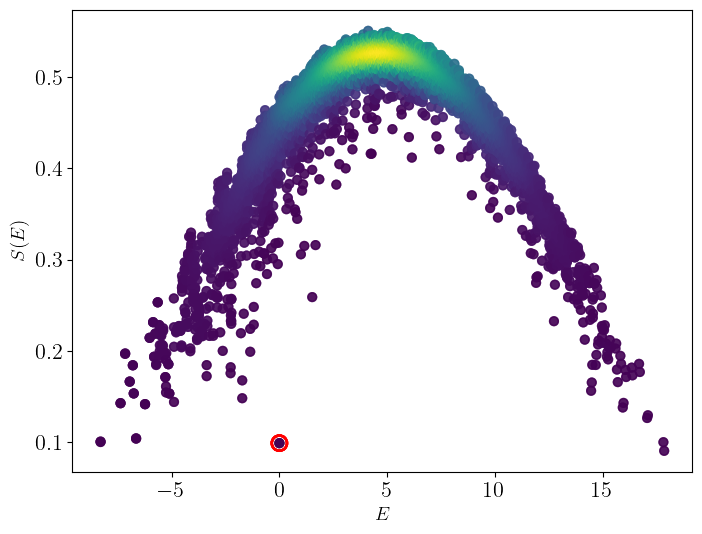

In [20]:
from scipy.stats import gaussian_kde
# Calculate point density for the entire plot area
xy = np.vstack([sort_E, sort_S])
density = gaussian_kde(xy)(xy)

# Plotting
plt.figure(figsize=(8, 6), dpi=100)
plt.scatter(sort_E, sort_S, c=density, s=40, cmap='viridis', alpha=0.7)
# Scar states
plt.scatter(
    sort_E[scar_idx0],
    sort_S[scar_idx0],
    facecolors='none',
    edgecolors='red',
    marker='o',
    s=120,
    linewidths=1.8,
    label='Scar states',
    zorder=3
)
# Labels and title with LaTeX formatting
plt.xlabel(r"$E$", fontsize=14)
plt.ylabel(r"$S(E)$", fontsize=14)
#plt.xlim(-0.2,0.2)
#plt.ylim(0.0,0.65)
plt.grid(False)
plt.savefig("Entropy_k1_chain_1_interface_L14.pdf",bbox_inches="tight")
plt.show()

In [21]:
degenerate_idx=[np.where(np.abs(sort_E)<1e-10)[0][0], np.where(np.abs(sort_E)<1e-10)[0][1], np.where(np.abs(sort_E)<1e-10)[0][2],np.where(np.abs(sort_E)<1e-10)[0][3]]
sort_energies_split = sort_E

n=len(degenerate_idx)
shifts=[-0.2,-0.1,0.1,0.2]

for i, idx in enumerate(degenerate_idx):
    sort_energies_split[idx] += shifts[i]

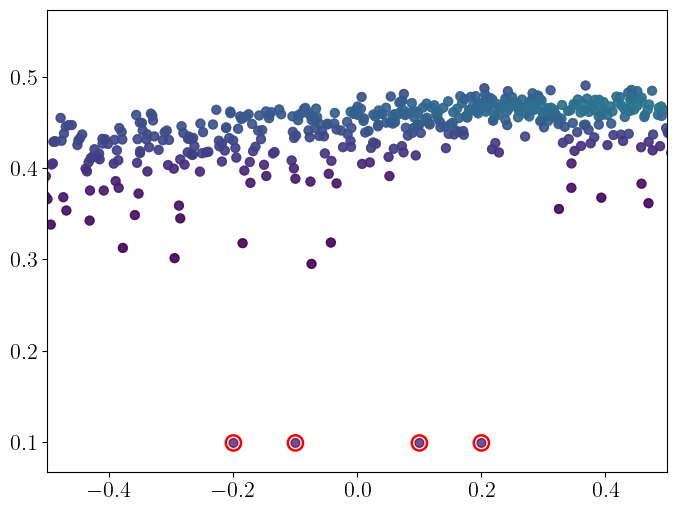

In [22]:
from scipy.stats import gaussian_kde
# Calculate point density for the entire plot area
xy = np.vstack([sort_E, sort_S])
density = gaussian_kde(xy)(xy)

# Plotting
plt.figure(figsize=(8, 6), dpi=100)
plt.scatter(sort_E, sort_S, c=density, s=40, cmap='viridis', alpha=0.7)
# Scar states
plt.scatter(
    sort_E[scar_idx0],
    sort_S[scar_idx0],
    facecolors='none',
    edgecolors='red',
    marker='o',
    s=120,
    linewidths=1.8,
    label='Scar states',
    zorder=3
)
# Labels and title with LaTeX formatting
#plt.xlabel(r"$E$", fontsize=14)
#plt.ylabel(r"$S(E)$", fontsize=14)
plt.xlim(-0.5,0.5)
plt.grid(False)
plt.savefig("Entropy_k1_chain_1_interface_inset_L14.pdf",bbox_inches="tight")
plt.show()